Data: drug target gene sets from [Enrichr](https://maayanlab.cloud/Enrichr/#libraries).

In [1]:
import glob
import importlib.metadata as md
import pandas as pd
import matplotlib.pyplot as plt
import eunoia as eu


## 1. Data

In [2]:
FOLDER = '../Drug target sample files'
A, S, U = 'Atorvastatin', 'Simvastatin', 'Sunitinib'

DATA = {}
for drug in (A, S, U):
    path = glob.glob(f'{FOLDER}/*{drug.upper()}_sample.csv')[0]
    DATA[drug] = sorted(set(pd.read_csv(path)['Gene names'].dropna()))

a, s, u = (set(DATA[d]) for d in (A, S, U))

# for name, region in [(A, a - s - u), (S, s - a - u), (U, u - a - s),
#                      (f'{A}&{S}', a & s - u), (f'{A}&{U}', a & u - s),
#                      (f'{S}&{U}', s & u - a), (f'{A}&{S}&{U}', a & s & u)]:
#     print(f'{name:36s} {len(region):3d}')

## 2. Before and after

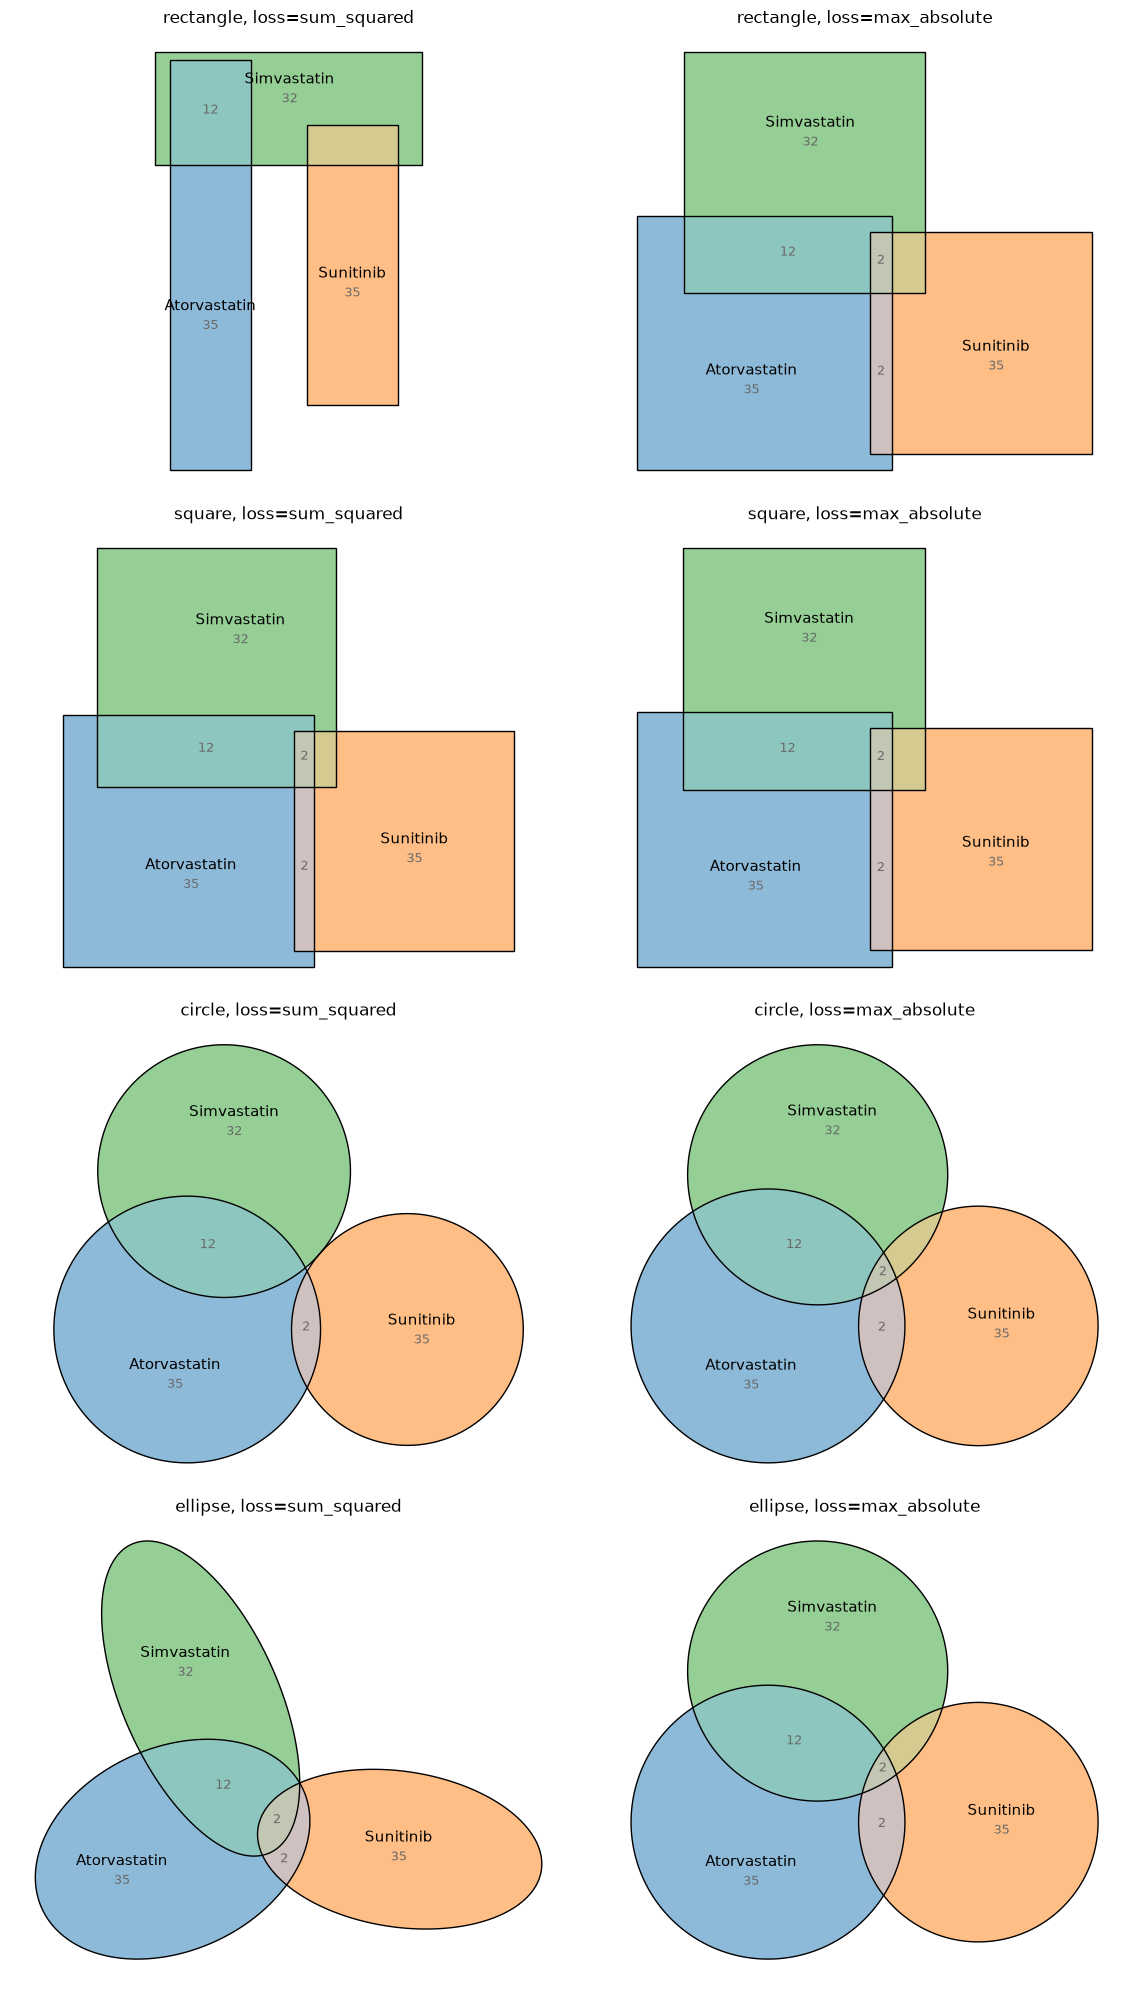

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
for row, shape in zip(axes, ('rectangle', 'square', 'circle', 'ellipse')):
    for ax, loss in zip(row, ('sum_squared', 'max_absolute')):
        fit = eu.euler(DATA, shape=shape, seed=0, loss=loss)
        fit.plot(ax=ax, quantities=True, legend=False)
        ax.set_title(f'{shape}, loss={loss}')
fig.tight_layout()
fig.savefig('eunoia_drug_before_after.png', dpi=110)
plt.show()

C:\Users\user\anaconda3\envs\viset\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


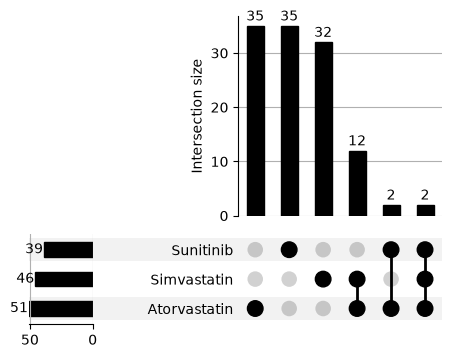

In [4]:
from upsetplot import UpSet, from_contents

upset = UpSet(from_contents(DATA), sort_by='cardinality', show_counts=True)
upset.plot()
plt.savefig('eunoia_drug_upset.png', dpi=110, bbox_inches='tight')
plt.show()